In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("spotify_alltime_top100_songs.csv")

In [3]:
df["is_mega_hit"] = df["total_streams_billions"].apply(lambda x: 1 if x >= 2 else 0 )

In [4]:
group_genre = {
    # Pop Group
    "Synth-Pop": "Pop",
    "Pop": "Pop",
    "Latin Pop": "Pop",
    "Indie Pop": "Pop",
    "Emo Rap": "Pop",
    "Pop Rap": "Pop",
    "Art Pop": "Pop",
    "Holiday Pop": "Pop",
    "Trap Pop": "Pop",
    "Folk Pop": "Pop",
    "Acoustic Pop": "Pop",
    "Pop Punk": "Pop",
    
    # Rock Group
    "Alt Rock": "Rock",
    "Pop Rock": "Rock",
    "Indie Rock": "Rock",
    "Art Rock": "Rock",

    # Hip-Hop Group
    "Hip-Hop": "Hip-Hop",
    "Hip-Hop/Pop": "Hip-Hop",

    # R&B/Soul Group
    "R&B": "R&B/Soul",
    "Pop/Soul": "R&B/Soul",
    "Soul/R&B": "R&B/Soul",
    "R&B/Soul": "R&B/Soul",
    "Pop/R&B": "R&B/Soul",

    # Other Group
    "Pop/Dancehall": "Others",
    "Afrobeats/Pop": "Others",
    "EDM/Pop": "Others",
    "Nu-Disco": "Others",
    "Pop/Folk": "Others",
    "Funk/Pop": "Others",
    "K-Pop/Pop": "Others",
    "Country/Pop": "Others",
    "Reggaeton": "Others",
    "Grunge": "Others",
    "Indie Folk": "Others",
    "Blues Rock": "Others",
    "Electropop": "Others",
    "Pop/Country": "Others",
    "R&B/Pop": "Others"
}

In [5]:
df["genre_group"] = df["primary_genre"].map(group_genre)

In [6]:
df["genre_group"] = df["genre_group"].fillna("Others")

In [7]:
df["explicit"] = df["explicit"].astype(int)

In [8]:
df = pd.get_dummies(df, columns=["genre_group"], drop_first=True)

In [9]:
df = df.drop(columns=[
    "alltime_rank",
    "song_title",
    "artist",
    "total_streams_billions",
    "primary_genre",
    "artist_country",
    "dataset_part"
])

In [10]:
x = df.drop(columns=["is_mega_hit"], axis=1)
y = df["is_mega_hit"]

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [12]:
# LogisticRegression
log_model = LogisticRegression(max_iter=100000)
log_model.fit(x_train, y_train)
y_prdd_lr = log_model.predict(x_test)

# RandomForest
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
y_prdd_rf = rf_model.predict(x_test)

# DecisionTreeClassifier
dtc_model = DecisionTreeClassifier()
dtc_model.fit(x_train, y_train)
y_prdd_dtc = dtc_model.predict(x_test)

print("All Models Train Sucessfully")

All Models Train Sucessfully


In [13]:
# Calculate accuracy for each model
lr_accuracy = accuracy_score(y_test, y_prdd_lr)
rf_accuracy = accuracy_score(y_test, y_prdd_rf)
dtc_accuracy = accuracy_score(y_test, y_prdd_dtc)

# Print results
print("Model Performance:")
print(f"Logistic Regression Accuracy: {lr_accuracy}")
print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"Decision Tree Accuracy: {dtc_accuracy}")

Model Performance:
Logistic Regression Accuracy: 0.6
Random Forest Accuracy: 0.65
Decision Tree Accuracy: 0.65


In [14]:
print(classification_report(y_test, y_prdd_lr))
print(classification_report(y_test, y_prdd_rf))
print(classification_report(y_test, y_prdd_dtc))

              precision    recall  f1-score   support

           0       0.50      0.12      0.20         8
           1       0.61      0.92      0.73        12

    accuracy                           0.60        20
   macro avg       0.56      0.52      0.47        20
weighted avg       0.57      0.60      0.52        20

              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.78      0.58      0.67        12

    accuracy                           0.65        20
   macro avg       0.66      0.67      0.65        20
weighted avg       0.68      0.65      0.65        20

              precision    recall  f1-score   support

           0       0.55      0.75      0.63         8
           1       0.78      0.58      0.67        12

    accuracy                           0.65        20
   macro avg       0.66      0.67      0.65        20
weighted avg       0.68      0.65      0.65        20



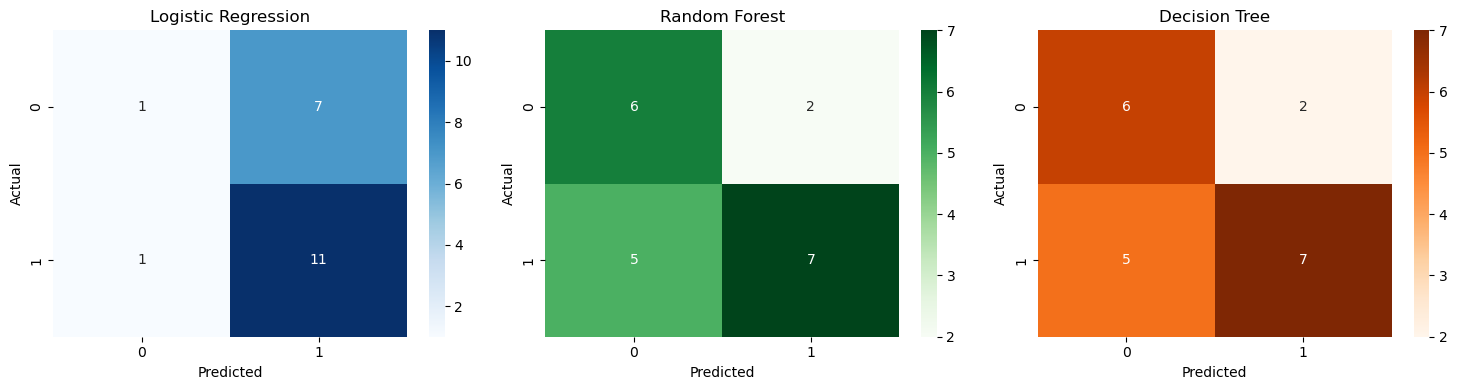

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_prdd_lr)
cm_rf = confusion_matrix(y_test, y_prdd_rf)
cm_dt = confusion_matrix(y_test, y_prdd_dtc)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Decision Tree')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()